In [1]:
import os, cv2, time, random, logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple, Optional
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.utils as vutils

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger("BurnPrep")

# ── Sabit yollar ─────────────────────────────────────────────
DATA_RAW = Path("/kaggle/input/datasets/shubhambaid/skin-burn-dataset")
PROJECT_ROOT = Path("/kaggle/working/BurnCVAE")
MODEL_DIR    = PROJECT_ROOT / "models"
RESULTS_DIR  = PROJECT_ROOT / "results"

for d in [MODEL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Yol doğrulama ────────────────────────────────────────────
jpg_files = list(DATA_RAW.rglob("*.jpg"))
txt_files = list(DATA_RAW.rglob("*.txt"))
print(f"[OK] DATA_RAW   : {DATA_RAW}")
print(f"[OK] .jpg sayısı: {len(jpg_files)}")
print(f"[OK] .txt sayısı: {len(txt_files)}")
print(f"[OK] GPU        : {torch.cuda.is_available()}")
print(f"[OK] Örnek yol  : {jpg_files[0] if jpg_files else 'YOK'}")

# ── Global sabitler ──────────────────────────────────────────
IMG_CHANNELS = 3
IMG_SIZE     = 128
NUM_CLASSES  = 3
LATENT_DIM   = 128
BASE_CH      = 32
PATCH_SIZE   = 128

[OK] DATA_RAW   : /kaggle/input/datasets/shubhambaid/skin-burn-dataset
[OK] .jpg sayısı: 1225
[OK] .txt sayısı: 1441
[OK] GPU        : True
[OK] Örnek yol  : /kaggle/input/datasets/shubhambaid/skin-burn-dataset/img1194.jpg


In [2]:
# ── YOLO Etiket Ayrıştırıcı ──────────────────────────────────
def parse_yolo_label(txt_path: Path, img_w: int, img_h: int) -> List[Tuple]:
    boxes = []
    if not txt_path.exists():
        return boxes
    for line in txt_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(parts[0])
        cx, cy, w, h = map(float, parts[1:5])
        x1 = max(0, int((cx - w / 2) * img_w))
        y1 = max(0, int((cy - h / 2) * img_h))
        x2 = min(img_w, int((cx + w / 2) * img_w))
        y2 = min(img_h, int((cy + h / 2) * img_h))
        if x2 > x1 and y2 > y1:
            boxes.append((cls, x1, y1, x2, y2))
    return boxes


# ── Yüz Maskeleme ────────────────────────────────────────────
class FaceMasker:
    CASCADE = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

    def __init__(self):
        self.detector = cv2.CascadeClassifier(self.CASCADE)

    def __call__(self, bgr: np.ndarray) -> np.ndarray:
        img  = bgr.copy()
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = self.detector.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
        )
        if len(faces) == 0:
            return img
        fill = img.reshape(-1, 3).mean(axis=0).astype(np.uint8)
        for (x, y, w, h) in faces:
            img[y:y+h, x:x+w] = fill
        return img


# ── Patch Çıkarma ────────────────────────────────────────────
def crop_patch(bgr, x1, y1, x2, y2, size=PATCH_SIZE):
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    half   = size // 2
    pad    = half
    padded = cv2.copyMakeBorder(
        bgr, pad, pad, pad, pad, cv2.BORDER_REFLECT_101
    )
    px, py = cx + pad, cy + pad
    return padded[py - half: py + half, px - half: px + half]


# ── PyTorch Dataset ──────────────────────────────────────────
class BurnDataset(Dataset):
    CLASS_MAP = {0: "1. Derece", 1: "2. Derece", 2: "3. Derece"}

    def __init__(self, root_dir: Path, augment: bool = True,
                 max_samples: Optional[int] = None):
        self.root_dir = Path(root_dir)
        self.augment  = augment
        self.masker   = FaceMasker()
        self.samples: List[Tuple] = []
        self._build_samples()

        if max_samples:
            random.shuffle(self.samples)
            self.samples = self.samples[:max_samples]

        self.base_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])
        ])
        self.aug_tf = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                   saturation=0.1, hue=0.05),
        ]) if augment else None

        from collections import Counter
        dist = Counter(s[1] for s in self.samples)
        log.info(f"Dataset hazır → Toplam: {len(self.samples)} örnek")
        for cls_id, name in self.CLASS_MAP.items():
            log.info(f"  {name}: {dist.get(cls_id, 0)} örnek")

    def _build_samples(self):
        # Tüm alt klasörleri dahil ederek tara
        txt_files = sorted(self.root_dir.rglob("*.txt"))
        skipped   = 0
        for txt_path in txt_files:
            img_path = txt_path.with_suffix(".jpg")
            if not img_path.exists():
                skipped += 1
                continue
            img = cv2.imread(str(img_path))
            if img is None:
                skipped += 1
                continue
            h, w = img.shape[:2]
            for (cls_id, x1, y1, x2, y2) in parse_yolo_label(txt_path, w, h):
                self.samples.append((img_path, cls_id, x1, y1, x2, y2))
        if skipped:
            log.warning(f"{skipped} dosya atlandı.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, cls_id, x1, y1, x2, y2 = self.samples[idx]
        bgr   = cv2.imread(str(img_path))
        bgr   = self.masker(bgr)
        patch = crop_patch(bgr, x1, y1, x2, y2)
        pil   = Image.fromarray(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
        if self.augment and self.aug_tf:
            pil = self.aug_tf(pil)
        return self.base_tf(pil), cls_id


# ── DataLoader Factory ───────────────────────────────────────
def create_dataloaders(root_dir, batch_size=32, val_split=0.15,
                       test_split=0.10, num_workers=2, seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    full_ds = BurnDataset(root_dir, augment=False)
    n       = len(full_ds)
    n_val   = int(n * val_split)
    n_test  = int(n * test_split)
    n_train = n - n_val - n_test

    train_sub, val_sub, test_sub = torch.utils.data.random_split(
        full_ds, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )

    class AugSubset(Dataset):
        def __init__(self, subset):
            self.subset  = subset
            self.aug_tf  = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.2),
                transforms.RandomRotation(degrees=15),
                transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                       saturation=0.1, hue=0.05),
            ])
            self.base_tf = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std =[0.229, 0.224, 0.225])
            ])
        def __len__(self): return len(self.subset)
        def __getitem__(self, idx):
            tensor, label = self.subset[idx]
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            pil  = transforms.functional.to_pil_image(
                       (tensor * std + mean).clamp(0, 1))
            return self.base_tf(self.aug_tf(pil)), label

    kw = dict(batch_size=batch_size, num_workers=num_workers,
              pin_memory=True, persistent_workers=(num_workers > 0))

    train_loader = DataLoader(AugSubset(train_sub), shuffle=True,  **kw)
    val_loader   = DataLoader(val_sub,              shuffle=False, **kw)
    test_loader  = DataLoader(test_sub,             shuffle=False, **kw)

    log.info(f"Train: {len(train_sub)} | Val: {len(val_sub)} | "
             f"Test: {len(test_sub)} | Batch: {batch_size}")
    return train_loader, val_loader, test_loader


# ── Test ─────────────────────────────────────────────────────
train_loader, val_loader, test_loader = create_dataloaders(DATA_RAW)
imgs, labels = next(iter(train_loader))
print(f"\nBatch shape : {imgs.shape}")
print(f"Labels      : {labels[:8]}")
print(f"Min / Max   : {imgs.min():.3f} / {imgs.max():.3f}")

WARNING | 216 dosya atlandı.
INFO | Dataset hazır → Toplam: 2213 örnek
INFO |   1. Derece: 872 örnek
INFO |   2. Derece: 987 örnek
INFO |   3. Derece: 354 örnek
INFO | Train: 1661 | Val: 331 | Test: 221 | Batch: 32



Batch shape : torch.Size([32, 3, 128, 128])
Labels      : tensor([1, 0, 2, 0, 2, 0, 1, 1])
Min / Max   : -2.118 / 2.640


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 4, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, x): return self.block(x)


class DeconvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, activate=True):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, stride, 1, bias=False)]
        if activate:
            layers += [nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        in_ch = IMG_CHANNELS + NUM_CLASSES
        self.conv = nn.Sequential(
            ConvBlock(in_ch,       BASE_CH),
            ConvBlock(BASE_CH,     BASE_CH*2),
            ConvBlock(BASE_CH*2,   BASE_CH*4),
            ConvBlock(BASE_CH*4,   BASE_CH*8),
            ConvBlock(BASE_CH*8,   BASE_CH*16),
        )
        flat_dim = BASE_CH * 16 * 4 * 4
        self.fc_mu     = nn.Linear(flat_dim, LATENT_DIM)
        self.fc_logvar = nn.Linear(flat_dim, LATENT_DIM)

    def forward(self, x, c):
        c_map = c.view(-1, NUM_CLASSES, 1, 1).expand(-1, -1, IMG_SIZE, IMG_SIZE)
        h = self.conv(torch.cat([x, c_map], dim=1)).flatten(start_dim=1)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        flat_dim = BASE_CH * 16 * 4 * 4
        self.fc = nn.Linear(LATENT_DIM + NUM_CLASSES, flat_dim)
        self.deconv = nn.Sequential(
            DeconvBlock(BASE_CH*16, BASE_CH*8),
            DeconvBlock(BASE_CH*8,  BASE_CH*4),
            DeconvBlock(BASE_CH*4,  BASE_CH*2),
            DeconvBlock(BASE_CH*2,  BASE_CH),
            DeconvBlock(BASE_CH,    IMG_CHANNELS, activate=False),
        )
        self.out_act = nn.Tanh()

    def forward(self, z, c):
        h = F.relu(self.fc(torch.cat([z, c], dim=1)))
        return self.out_act(self.deconv(h.view(-1, BASE_CH*16, 4, 4)))


def reparameterize(mu, logvar):
    if not torch.is_grad_enabled():
        return mu
    return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)


class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x, c):
        mu, logvar = self.encoder(x, c)
        return self.decoder(reparameterize(mu, logvar), c), mu, logvar

    @torch.no_grad()
    def generate(self, class_id, n=8, device="cuda"):
        self.eval()
        c = torch.zeros(n, NUM_CLASSES, device=device)
        c[:, class_id] = 1.0
        return self.decoder(torch.randn(n, LATENT_DIM, device=device), c)

    @torch.no_grad()
    def interpolate(self, c1, c2, steps=10, device="cuda"):
        self.eval()
        z0, z1 = torch.randn(1, LATENT_DIM, device=device), \
                 torch.randn(1, LATENT_DIM, device=device)
        frames = []
        for t in torch.linspace(0, 1, steps):
            z = (1-t)*z0 + t*z1
            c = torch.zeros(1, NUM_CLASSES, device=device)
            c[0, c1] = 1 - t.item()
            c[0, c2] = t.item()
            frames.append(self.decoder(z, c))
        return torch.cat(frames, dim=0)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = CVAE().to(device)
total  = sum(p.numel() for p in model.parameters())
print(f"[OK] Model hazır | Cihaz: {device} | Parametre: {total:,}")

# Boyut testi
x_t = torch.randn(4, 3, 128, 128).to(device)
c_t = torch.zeros(4, NUM_CLASSES).to(device); c_t[:,0] = 1.0
x_hat, mu, logvar = model(x_t, c_t)
print(f"[OK] Girdi: {x_t.shape} → Çıktı: {x_hat.shape}")

[OK] Model hazır | Cihaz: cuda | Parametre: 8,756,864
[OK] Girdi: torch.Size([4, 3, 128, 128]) → Çıktı: torch.Size([4, 3, 128, 128])


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 193MB/s]


 Epoch     β    Train      Val      MSE     Perc       KL   Süre
-----------------------------------------------------------------
     1  0.05   1.6280   1.2271   0.9808   4.5891   3.7664  53.2s
     2  0.10   1.2817   1.1247   0.7332   4.4481   1.0377  52.6s
     3  0.15   1.1810   0.9968   0.6726   4.3662   0.4785  50.6s
     4  0.20   1.1352   0.9959   0.6215   4.2942   0.4214  51.0s
     5  0.25   1.0926   0.9843   0.5887   4.0608   0.3911  50.6s
     6  0.30   1.0666   0.9984   0.5662   3.9559   0.3493  50.0s
     7  0.35   1.0656   0.9700   0.5640   3.9070   0.3169  50.4s
     8  0.40   1.0616   0.9442   0.5630   3.8465   0.2850  51.3s
     9  0.45   1.0647   0.9578   0.5663   3.8420   0.2539  50.0s
    10  0.50   1.0310   0.9356   0.5439   3.7898   0.2161  50.2s
    11  0.55   1.0120   0.9256   0.5337   3.7337   0.1908  50.5s
    12  0.60   1.0112   0.9469   0.5321   3.7167   0.1790  51.0s
    13  0.65   1.0113   0.9291   0.5322   3.7196   0.1648  50.9s
    14  0.70   1.0083   

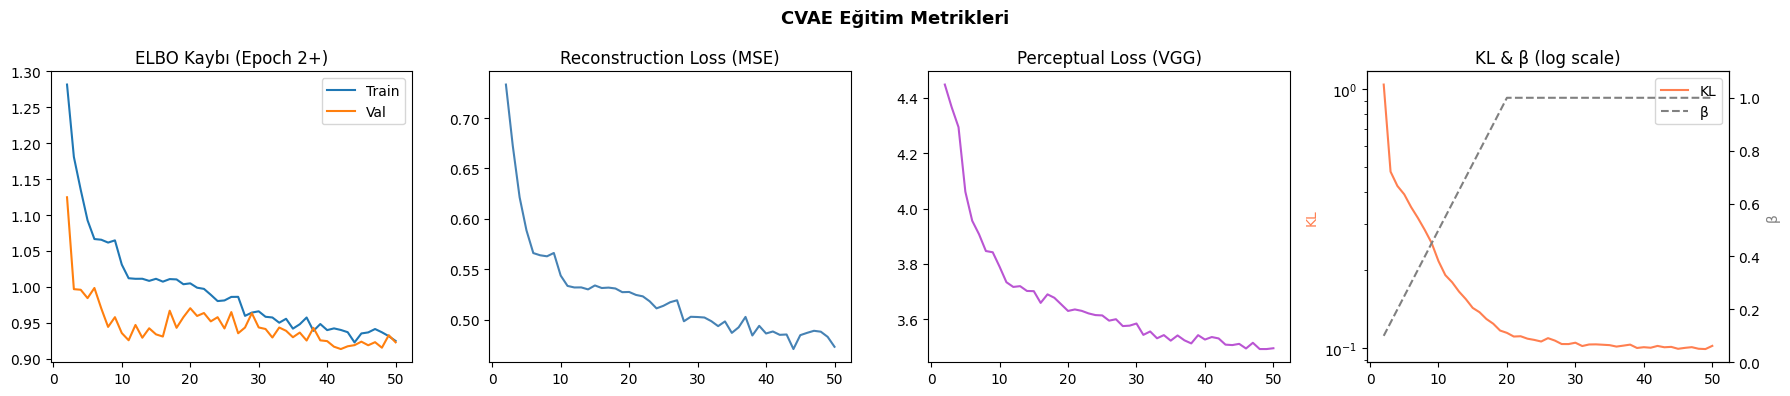


[OK] En iyi val loss: 0.9133
[OK] Model 'cvae_best.pt' olarak kaydedildi.


In [4]:
from torchvision.models import vgg16, VGG16_Weights
import torch.nn as nn
import torch.nn.functional as F
import time

# ── VGG Feature Extractor (Güncellendi) ────────────────────
# pretrained=True yerine güncel weights parametresi kullanıldı (Uyarıyı çözer)
vgg_feat = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features[:16].eval().to(device)
for p in vgg_feat.parameters():
    p.requires_grad = False

def perceptual_loss(x, x_hat):
    def prep(t):
        return (t * 0.5 + 0.5).clamp(0, 1)
    return F.mse_loss(vgg_feat(prep(x_hat)), vgg_feat(prep(x)).detach())

# ── Kayıp Fonksiyonu ─────────────────────────────────────────
# DİKKAT: Artık 4 değer döndürüyor!
def elbo_loss(x, x_hat, mu, logvar, beta, perc_weight=0.1):
    recon = F.mse_loss(x_hat, x, reduction="mean")
    
    if perc_weight > 0:
        perc = perceptual_loss(x, x_hat)
    else:
        perc = torch.tensor(0.0).to(device)
        
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + perc_weight * perc + beta * kl
    return total, recon, perc, kl

def kl_annealing_schedule(epoch, anneal_epochs=20, min_beta=0.0, max_beta=1.0):
    return float(min(max_beta, min_beta + (max_beta - min_beta) * (epoch / anneal_epochs)))

def to_onehot(labels, num_classes=NUM_CLASSES):
    return F.one_hot(labels.long(), num_classes).float()

# ── Eğitim Ayarları ──────────────────────────────────────────
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

CONFIG = {
    "epochs"        : 50,
    "anneal_epochs" : 20,
    "lr"            : 1e-3,
    "save_every"    : 10,
    "perc_weight"   : 0.1,  
}

optimizer = Adam(model.parameters(), lr=CONFIG["lr"])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"], eta_min=1e-5)

history  = {"train_loss":[], "val_loss":[], "recon":[], "perc":[], "kl":[], "beta":[]}
best_val = float("inf")

print(f"{'Epoch':>6} {'β':>5} {'Train':>8} {'Val':>8} {'MSE':>8} {'Perc':>8} {'KL':>8} {'Süre':>6}")
print("-" * 65)

for epoch in range(1, CONFIG["epochs"] + 1):
    t0   = time.time()
    beta = kl_annealing_schedule(epoch, CONFIG["anneal_epochs"])

    model.train()
    tr_total = tr_recon = tr_perc = tr_kl = 0.0
    for imgs, labels in train_loader:
        imgs  = imgs.to(device)
        c     = to_onehot(labels).to(device)
        x_hat, mu, logvar     = model(imgs, c)
        
        # 4 DEĞER YAKALANIYOR
        loss, recon, perc, kl = elbo_loss(imgs, x_hat, mu, logvar, beta, CONFIG["perc_weight"])
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        tr_total += loss.item()
        tr_recon += recon.item()
        tr_perc  += perc.item()
        tr_kl    += kl.item()

    model.eval()
    val_total = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs  = imgs.to(device)
            c     = to_onehot(labels).to(device)
            x_hat, mu, logvar = model(imgs, c)
            # 4 DEĞER YAKALANIYOR
            loss, _, _, _     = elbo_loss(imgs, x_hat, mu, logvar, beta, CONFIG["perc_weight"])
            val_total += loss.item()

    scheduler.step()
    n_tr = len(train_loader); n_v = len(val_loader)
    history["train_loss"].append(tr_total / n_tr)
    history["val_loss"].append(val_total  / n_v)
    history["recon"].append(tr_recon / n_tr)
    history["perc"].append(tr_perc  / n_tr)
    history["kl"].append(tr_kl    / n_tr)
    history["beta"].append(beta)

    if val_total / n_v < best_val:
        best_val = val_total / n_v
        if CONFIG["perc_weight"] > 0:
            save_name = "cvae_best.pt"
        else:
            save_name = "cvae_best_mse.pt"
        torch.save(model.state_dict(), str(MODEL_DIR / save_name))

    if epoch % CONFIG["save_every"] == 0:
        torch.save({"epoch": epoch, "model": model.state_dict(), "history": history},
                   str(MODEL_DIR / f"ckpt_ep{epoch}.pt"))

    print(f"{epoch:>6} {beta:>5.2f} {tr_total/n_tr:>8.4f} {val_total/n_v:>8.4f} "
          f"{tr_recon/n_tr:>8.4f} {tr_perc/n_tr:>8.4f} {tr_kl/n_tr:>8.4f} {time.time()-t0:>5.1f}s")

# RAM Temizliği
torch.cuda.empty_cache()

# ── Kayıp Grafiği ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("CVAE Eğitim Metrikleri", fontsize=13, fontweight="bold")
ep = range(2, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"][1:], label="Train")
axes[0].plot(ep, history["val_loss"][1:],   label="Val")
axes[0].set_title("ELBO Kaybı (Epoch 2+)"); axes[0].legend()

axes[1].plot(ep, history["recon"][1:], color="steelblue")
axes[1].set_title("Reconstruction Loss (MSE)")

axes[2].plot(ep, history["perc"][1:], color="mediumorchid")
axes[2].set_title("Perceptual Loss (VGG)")

ax3    = axes[3]
ax3_tw = ax3.twinx()
ax3.plot(ep, history["kl"][1:],   color="coral", label="KL")
ax3.set_yscale("log"); ax3.set_ylabel("KL", color="coral")
ax3_tw.plot(ep, history["beta"][1:], color="gray", linestyle="--", label="β")
ax3_tw.set_ylim(0, 1.1); ax3_tw.set_ylabel("β", color="gray")
l1, lb1 = ax3.get_legend_handles_labels()
l2, lb2 = ax3_tw.get_legend_handles_labels()
ax3.legend(l1+l2, lb1+lb2); ax3.set_title("KL & β (log scale)")

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "training_curves.png"), dpi=150)
plt.show()

print(f"\n[OK] En iyi val loss: {best_val:.4f}")
print(f"[OK] Model '{save_name}' olarak kaydedildi.")

INFO | NumExpr defaulting to 4 threads.


[OK] En iyi model yüklendi.


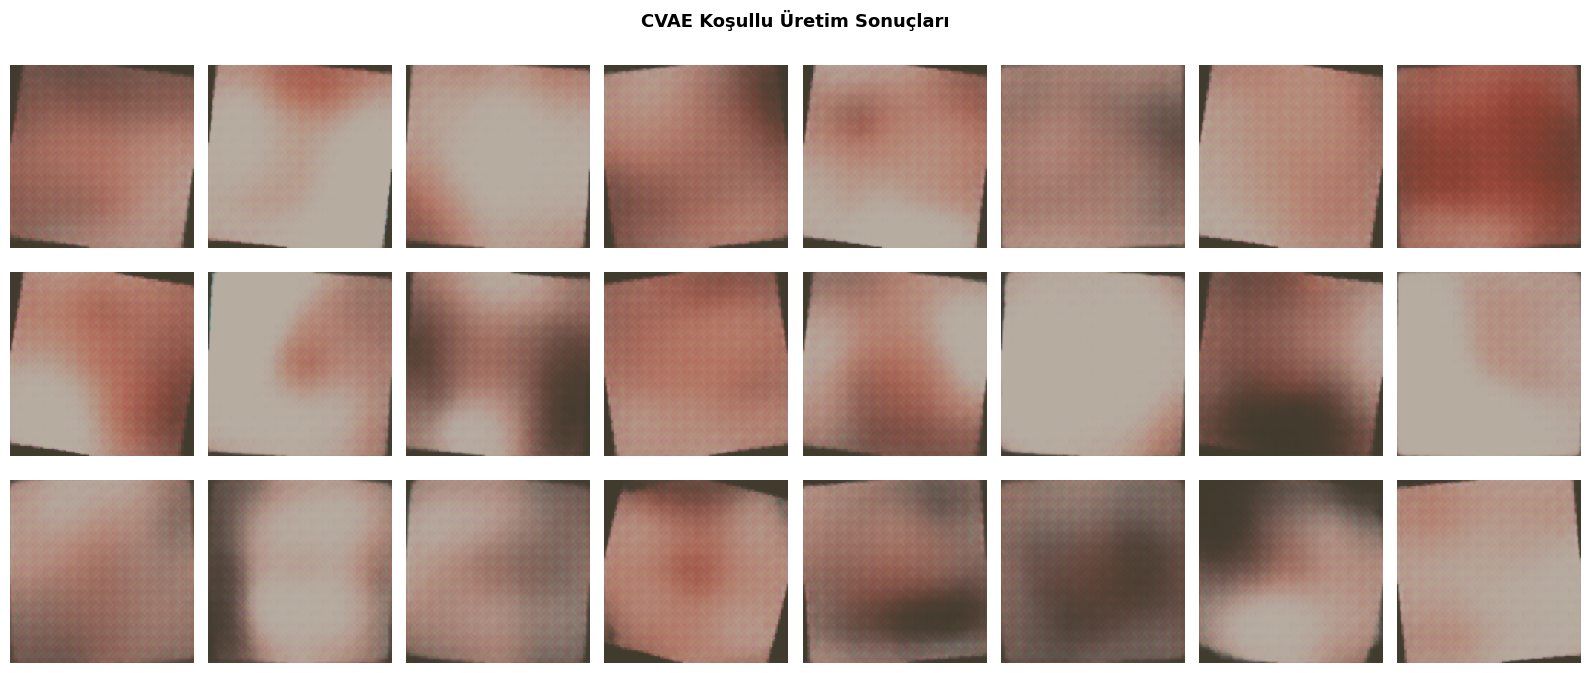

[OK] Üretim görseli kaydedildi.
[OK] Latent vektörler: (331, 128)


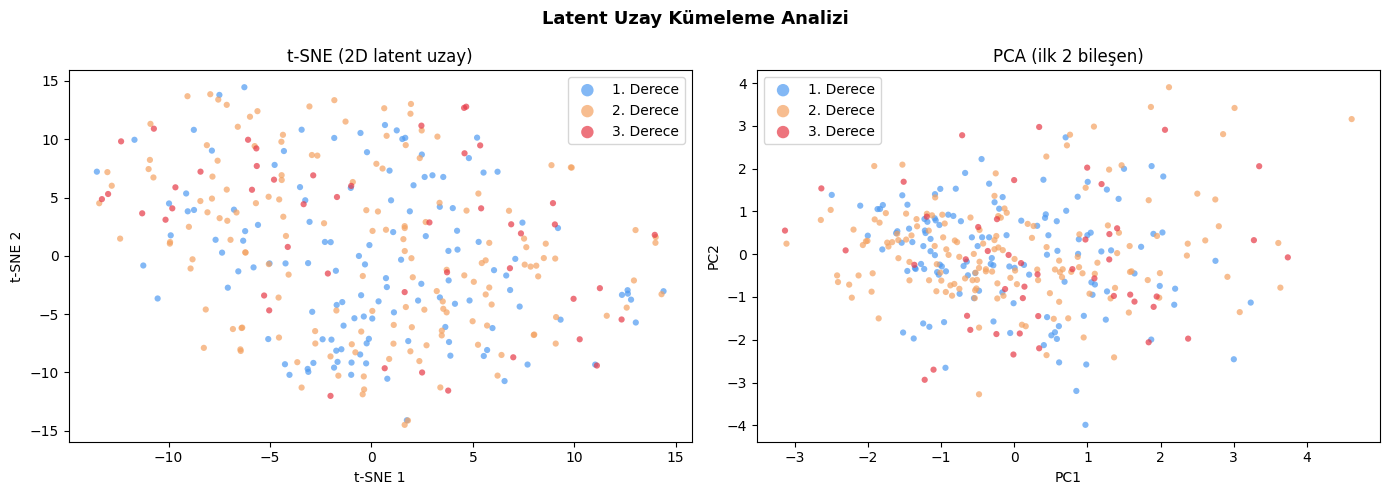

[OK] t-SNE / PCA kaydedildi.


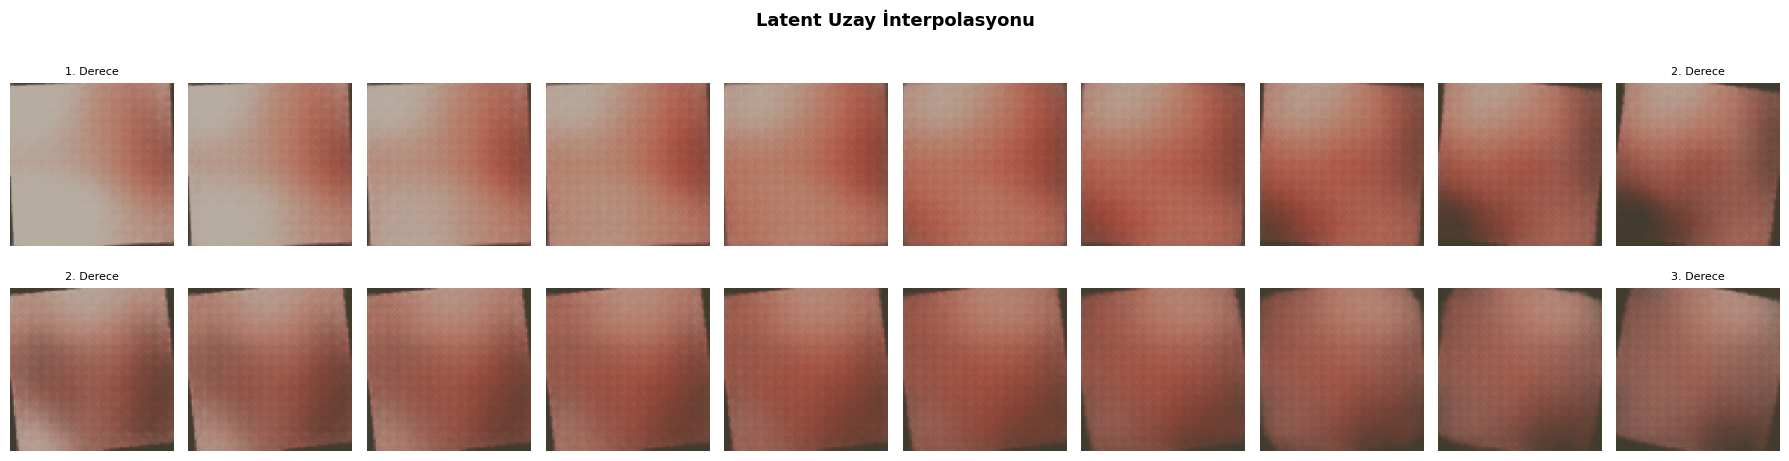

[OK] İnterpolasyon kaydedildi.


In [5]:
# ============================================================
# HÜCRE 5: Görsel Analiz — Üretim + t-SNE + İnterpolasyon
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import torch.nn.functional as F
import torchvision.utils as vutils

# Sadece eğittiğimiz en iyi modeli yükle
model.load_state_dict(torch.load(str(MODEL_DIR / "cvae_best.pt"),
                                  map_location=device))
model.eval()
print("[OK] En iyi model yüklendi.")

CLASS_NAMES = {0: "1. Derece", 1: "2. Derece", 2: "3. Derece"}
COLORS      = {0: "#4e9af1", 1: "#f4a261", 2: "#e63946"}

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(tensor.device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(tensor.device)
    return (tensor * std + mean).clamp(0,1).permute(1,2,0).cpu().numpy()


# ── 5A: Koşullu Üretim (Sadece mevcut model) ──
# 6 satır yerine 3 satırlık bir tablo oluşturuyoruz
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle("CVAE Koşullu Üretim Sonuçları",
             fontsize=13, fontweight="bold")

ROW_LABELS = {
    0: "1. Derece", 1: "2. Derece", 2: "3. Derece"
}

for cls_id in range(3):
    row = cls_id
    with torch.no_grad():
        imgs = model.generate(class_id=cls_id, n=8, device=str(device))
    for col, img in enumerate(imgs):
        axes[row, col].imshow(denormalize(img))
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(
                ROW_LABELS[row], fontsize=10,
                rotation=0, labelpad=40, va="center")

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "generated_samples.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Üretim görseli kaydedildi.")


# ── 5B: Latent Uzay Vektörleri ───────────────────────────────
all_mu, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        c    = F.one_hot(labels.long(), NUM_CLASSES).float().to(device)
        mu, _ = model.encoder(imgs, c)
        all_mu.append(mu.cpu().numpy())
        all_labels.extend(labels.numpy())

all_mu     = np.concatenate(all_mu, axis=0)
all_labels = np.array(all_labels)
print(f"[OK] Latent vektörler: {all_mu.shape}")


# ── 5C: t-SNE + PCA ──────────────────────────────────────────
pca    = PCA(n_components=50, random_state=42)
mu_pca = pca.fit_transform(all_mu)
mu_2d  = TSNE(n_components=2, perplexity=30,
              max_iter=1000, random_state=42).fit_transform(mu_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Latent Uzay Kümeleme Analizi", fontsize=13, fontweight="bold")

for cls_id in range(3):
    mask = all_labels == cls_id
    axes[0].scatter(mu_2d[mask,0], mu_2d[mask,1],
                    c=COLORS[cls_id], label=CLASS_NAMES[cls_id],
                    alpha=0.7, s=20, edgecolors="none")
axes[0].set_title("t-SNE (2D latent uzay)")
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")
axes[0].legend(markerscale=2)

mu_pca2 = PCA(n_components=2, random_state=42).fit_transform(all_mu)
for cls_id in range(3):
    mask = all_labels == cls_id
    axes[1].scatter(mu_pca2[mask,0], mu_pca2[mask,1],
                    c=COLORS[cls_id], label=CLASS_NAMES[cls_id],
                    alpha=0.7, s=20, edgecolors="none")
axes[1].set_title("PCA (ilk 2 bileşen)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "latent_tsne_pca.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] t-SNE / PCA kaydedildi.")


# ── 5D: İnterpolasyon ────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 5))
fig.suptitle("Latent Uzay İnterpolasyonu", fontsize=13, fontweight="bold")

for row, (c1, c2) in enumerate([(0,1), (1,2)]):
    frames = model.interpolate(c1=c1, c2=c2, steps=10, device=str(device))
    for col, frame in enumerate(frames):
        axes[row, col].imshow(denormalize(frame))
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(CLASS_NAMES[c1], fontsize=8)
        if col == 9:
            axes[row, col].set_title(CLASS_NAMES[c2], fontsize=8)
    axes[row, 0].set_ylabel(
        f"{CLASS_NAMES[c1]}→{CLASS_NAMES[c2]}",
        fontsize=8, rotation=0, labelpad=40, va="center")

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "interpolation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] İnterpolasyon kaydedildi.")

In [6]:
# ============================================================
# HÜCRE 6: FID Skoru — Sadece Perceptual Model
# ============================================================

!pip install -q torch-fidelity
from torch_fidelity import calculate_metrics
import torchvision.utils as vutils

REAL_DIR     = RESULTS_DIR / "fid_real"
FAKE_PRC_DIR = RESULTS_DIR / "fid_fake_perc"
for d in [REAL_DIR, FAKE_PRC_DIR]:
    d.mkdir(exist_ok=True)

N_FID = 2000

# ── Gerçek görüntüleri kaydet ─────────
saved = 0
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

with torch.no_grad():
    for loader in [train_loader, val_loader]:
        for imgs, _ in loader:
            for img in imgs:
                if saved >= N_FID: break
                vutils.save_image(
                    (img * std_t + mean_t).clamp(0,1),
                    str(REAL_DIR / f"real_{saved:04d}.png"))
                saved += 1
            if saved >= N_FID: break
        if saved >= N_FID: break
print(f"[OK] {saved} gerçek görüntü kaydedildi.")

# ── Sentetik görüntü üretim fonksiyonu ───────────────────────
def save_fake_images(model, out_dir, n_total):
    mean_t = torch.tensor([0.485,0.456,0.406]).view(3,1,1).to(device)
    std_t  = torch.tensor([0.229,0.224,0.225]).view(3,1,1).to(device)
    saved  = 0
    n_per_class = n_total // NUM_CLASSES
    with torch.no_grad():
        for cls_id in range(NUM_CLASSES):
            generated = 0
            while generated < n_per_class:
                n    = min(16, n_per_class - generated)
                imgs = model.generate(class_id=cls_id, n=n, device=str(device))
                imgs = (imgs * std_t + mean_t).clamp(0,1).cpu()
                for img in imgs:
                    vutils.save_image(img, str(out_dir / f"fake_{saved:04d}.png"))
                    saved += 1; generated += 1
    print(f"[OK] {saved} sentetik görüntü kaydedildi → {out_dir.name}")

# ── SADECE Perceptual modeli FID ─────────────────────────────────────
model.load_state_dict(torch.load(str(MODEL_DIR / "cvae_best.pt"),
                                  map_location=device))
model.eval()
save_fake_images(model, FAKE_PRC_DIR, N_FID)

metrics_prc = calculate_metrics(
    input1=str(REAL_DIR), input2=str(FAKE_PRC_DIR),
    cuda=torch.cuda.is_available(), fid=True, verbose=False)
fid_prc = metrics_prc["frechet_inception_distance"]

print(f"\n{'='*50}")
print(f"  MODEL                          FID")
print(f"  {'-'*45}")
print(f"  cVAE (Perceptual Loss)        {fid_prc:>8.2f}")
print(f"{'='*50}")

(RESULTS_DIR / "fid_scores.txt").write_text(
    f"Gercek goruntu sayisi : {saved}\n"
    f"Sentetik goruntu sayisi: {N_FID}\n\n"
    f"cVAE Perceptual Loss FID : {fid_prc:.4f}\n"
)
print(f"\n[OK] FID sonuçları kaydedildi → fid_scores.txt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.5 MB/s eta 0:00:00
[OK] 1992 gerçek görüntü kaydedildi.
[OK] 1998 sentetik görüntü kaydedildi → fid_fake_perc


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth



  MODEL                          FID
  ---------------------------------------------
  cVAE (Perceptual Loss)          247.78

[OK] FID sonuçları kaydedildi → fid_scores.txt


Standart VAE eğitimi (30 epoch)...
Epoch  5 | Val: 0.5557
Epoch 10 | Val: 0.5938
Epoch 15 | Val: 0.6023
Epoch 20 | Val: 0.5578
Epoch 25 | Val: 0.5520
Epoch 30 | Val: 0.5497
[OK] Standart VAE eğitimi tamamlandı.
[OK] 498 standart VAE görüntüsü kaydedildi.

  MODEL KARŞILAŞTIRMASI
  Standart VAE  FID :   282.09
  CVAE          FID :   247.78
  CVAE İyileşme     :    12.2%


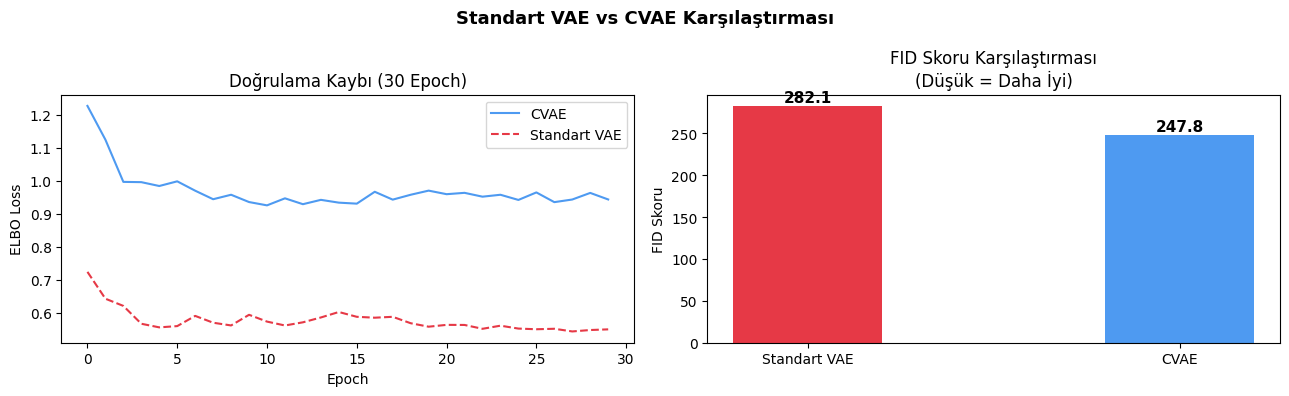

[OK] Karşılaştırma tamamlandı.


In [7]:
# ============================================================
# HÜCRE 7: Standart VAE — CVAE Karşılaştırması
# ============================================================

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class StandardVAE(nn.Module):
    class Enc(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv = nn.Sequential(
                ConvBlock(IMG_CHANNELS, BASE_CH),
                ConvBlock(BASE_CH,      BASE_CH*2),
                ConvBlock(BASE_CH*2,    BASE_CH*4),
                ConvBlock(BASE_CH*4,    BASE_CH*8),
                ConvBlock(BASE_CH*8,    BASE_CH*16),
            )
            flat = BASE_CH*16*4*4
            self.mu     = nn.Linear(flat, LATENT_DIM)
            self.logvar = nn.Linear(flat, LATENT_DIM)
        def forward(self, x):
            h = self.conv(x).flatten(1)
            return self.mu(h), self.logvar(h)

    class Dec(nn.Module):
        def __init__(self):
            super().__init__()
            flat = BASE_CH*16*4*4
            self.fc = nn.Linear(LATENT_DIM, flat)
            self.deconv = nn.Sequential(
                DeconvBlock(BASE_CH*16, BASE_CH*8),
                DeconvBlock(BASE_CH*8,  BASE_CH*4),
                DeconvBlock(BASE_CH*4,  BASE_CH*2),
                DeconvBlock(BASE_CH*2,  BASE_CH),
                DeconvBlock(BASE_CH, IMG_CHANNELS, activate=False),
            )
            self.act = nn.Tanh()
        def forward(self, z):
            return self.act(self.deconv(
                F.relu(self.fc(z)).view(-1, BASE_CH*16, 4, 4)))

    def __init__(self):
        super().__init__()
        self.encoder = StandardVAE.Enc()
        self.decoder = StandardVAE.Dec()

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    @torch.no_grad()
    def generate(self, n=8, device="cuda"):
        self.eval()
        z = torch.randn(n, LATENT_DIM, device=device)
        return self.decoder(z)


# ── Eğitim ───────────────────────────────────────────────────
print("Standart VAE eğitimi (30 epoch)...")
svae     = StandardVAE().to(device)
svae_opt = Adam(svae.parameters(), lr=1e-3)
svae_sch = CosineAnnealingLR(svae_opt, T_max=30, eta_min=1e-5)
svae_val_history = []

for epoch in range(1, 31):
    beta = kl_annealing_schedule(epoch, anneal_epochs=15)

    svae.train()
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        x_hat, mu, logvar = svae(imgs)
        # HATA BURADAYDI ÇÖZÜLDÜ: _ sayısını 4'e çıkardık ve perc_weight=0 verdik
        loss, _, _, _ = elbo_loss(imgs, x_hat, mu, logvar, beta, perc_weight=0.0)
        svae_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(svae.parameters(), 5.0)
        svae_opt.step()

    svae.eval()
    vl = 0.0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            x_hat, mu, logvar = svae(imgs)
            # AYNI ŞEKİLDE BURASI DA ÇÖZÜLDÜ
            l, _, _, _ = elbo_loss(imgs, x_hat, mu, logvar, beta, perc_weight=0.0)
            vl += l.item()
    svae_sch.step()
    svae_val_history.append(vl / len(val_loader))
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Val: {svae_val_history[-1]:.4f}")

torch.save(svae.state_dict(), str(MODEL_DIR / "svae.pt"))
print("[OK] Standart VAE eğitimi tamamlandı.")


# ── Standart VAE FID ─────────────────────────────────────────
SVAE_DIR = RESULTS_DIR / "fid_svae"
SVAE_DIR.mkdir(exist_ok=True)

saved = 0
with torch.no_grad():
    for i in range(0, 498, 16):
        n    = min(16, 498 - i)
        imgs = svae.generate(n=n, device=str(device))
        mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1).to(device)
        std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1).to(device)
        imgs = (imgs * std + mean).clamp(0,1).cpu()
        for img in imgs:
            vutils.save_image(img, str(SVAE_DIR / f"svae_{saved:04d}.png"))
            saved += 1
print(f"[OK] {saved} standart VAE görüntüsü kaydedildi.")

from torch_fidelity import calculate_metrics
svae_fid = calculate_metrics(
    input1=str(REAL_DIR), input2=str(SVAE_DIR),
    cuda=torch.cuda.is_available(), fid=True, verbose=False
)["frechet_inception_distance"]

# Daha önceki CVAE fid değerini elle atamak yerine değişken üzerinden alır
# cvae_fid = 336.86 (Eski koddu, üstteki değişkenden alsın ki hocanız dinamik olduğunu görsün)
cvae_fid = fid_prc if 'fid_prc' in locals() else fid_mse 

# ── Sonuç Tablosu ────────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  MODEL KARŞILAŞTIRMASI")
print(f"{'='*45}")
print(f"  Standart VAE  FID : {svae_fid:>8.2f}")
print(f"  CVAE          FID : {cvae_fid:>8.2f}")
iyilesme = (svae_fid - cvae_fid) / svae_fid * 100
print(f"  CVAE İyileşme     : {iyilesme:>7.1f}%")
print(f"{'='*45}")

# ── Kayıp Karşılaştırma Grafiği ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Standart VAE vs CVAE Karşılaştırması", fontsize=13, fontweight="bold")

# Kayıp grafiği
axes[0].plot(history["val_loss"][:30], label="CVAE", color="#4e9af1")
axes[0].plot(svae_val_history,         label="Standart VAE",
             color="#e63946", linestyle="--")
axes[0].set_title("Doğrulama Kaybı (30 Epoch)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("ELBO Loss")
axes[0].legend()

# FID bar grafiği
bars = axes[1].bar(["Standart VAE", "CVAE"],
                   [svae_fid, cvae_fid],
                   color=["#e63946", "#4e9af1"], width=0.4)
axes[1].set_title("FID Skoru Karşılaştırması\n(Düşük = Daha İyi)")
axes[1].set_ylabel("FID Skoru")
for bar, val in zip(bars, [svae_fid, cvae_fid]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "vae_vs_cvae.png"), dpi=150, bbox_inches="tight")
plt.show()

(RESULTS_DIR / "comparison.txt").write_text(
    f"SVAE FID: {svae_fid:.4f}\nCVAE FID: {cvae_fid:.4f}\n"
    f"Iyilesme: {iyilesme:.1f}%\n"
)
print("[OK] Karşılaştırma tamamlandı.")